# Assignment 1: Introduction to Reinforcement Learning (RL)
### Core Paradigms, Agent-Environment Formulation, and Real-World Applications

Reinforcement Learning (RL) is a paradigm of machine learning where an autonomous **agent** learns to make sequential decisions by interacting with a dynamic **environment** through trial and error, guided by scalar **reward signals**, to maximize cumulative long-term return.

This notebook covers:
1. **Supervised vs. Unsupervised vs. Reinforcement Learning**: A comparative analysis with real-world examples from Instagram, Spotify, and Chess AI.
2. **Step-by-Step RL Formulation (Zomato Recommendation Engine)**: Deconstructing Agent, Environment, States, Actions, and Rewards.
3. **RL Design for an IPL Cricket Fantasy League**: Architecting states, action spaces, and fantasy-point reward functions with a Python simulation.
4. **App Improvement via RL (YouTube Autoplay & Next-Video Recommendation)**: Mitigating clickbait traps, optimizing long-term user satisfaction, and simulating a contextual recommendation bandit.


---
## Question 1: Differences Between Supervised, Unsupervised, and Reinforcement Learning

### Problem Statement
List 3 differences between **Reinforcement Learning**, **Supervised Learning**, and **Unsupervised Learning** in a table, using real examples from apps like **Instagram** (feed ranking), **Spotify** (music recommendations), and **chess game AI**.

---

### Comparative Analysis Table

| Dimension | Supervised Learning (SL) | Unsupervised Learning (UL) | Reinforcement Learning (RL) |
| :--- | :--- | :--- | :--- |
| **1. Nature of Feedback & Data** | **Explicit Ground-Truth Labels**: Trained on labeled input-output pairs $(X, y)$. Directly told the correct target for each example. | **No Labels or External Feedback**: Discovers latent structure, geometric clusters, or probability densities directly from unlabeled inputs $(X)$. | **Evaluative Reward Signals**: No ground-truth "correct" actions provided. Receives delayed scalar rewards/penalties $(R_t)$ via trial-and-error exploration. |
| **2. Decision Timeline & Feedback Delay** | **Instantaneous, Independent Predictions**: Predictions on one input do not alter future inputs ($i.i.d.$ assumption). Immediate loss minimization. | **Static Data Discovery**: Groupings and manifold projections are computed across the dataset without sequential time dependencies. | **Sequential Decision Making**: Actions taken today alter the environment's state and dictate future states and long-term cumulative returns. |
| **3. Learning Objective** | **Minimize Prediction Error**: Fits a mapping function $f(X) \to y$ (e.g. cross-entropy or MSE loss). | **Structure Discovery / Compression**: Maximizes cluster cohesion, variance explained, or data log-likelihood. | **Maximize Cumulative Return**: Solves an optimal policy $\pi^*(a \mid s)$ that maximizes expected discounted return $\sum_{t} \gamma^t R_t$. |
| **Real App Example: Instagram (Feed Ranking)** | Predicting whether a user will like a post given their past history ($y \in \{0, 1\}$). | Clustering users into behavioral segments (e.g., foodies, fitness enthusiasts, tech geeks). | Dynamically ordering posts and reels in real-time to maximize total 30-day session retention without fatigue. |
| **Real App Example: Spotify (Music Recommendations)** | Predicting song rating or thumbs-up probability from audio acoustic features. | Grouping millions of tracks into latent acoustic clusters (e.g. acoustic chill, workout EDM). | Dynamic playlist sequencing: deciding the next song to play to prevent track skips and maximize total listening session length. |
| **Real App Example: Chess Game AI** | Training an evaluation network on millions of grandmaster games to predict the winner from a static board. | Clustering board positions to discover similar opening pawn structures without knowing who won. | **AlphaZero / Stockfish RL**: Playing millions of self-play games through trial-and-error, discovering tactical sacrifices to maximize checkmate wins (+1 win, -1 loss). |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Displaying comparison summary table in Python
comparison_data = {
    "Learning Paradigm": ["Supervised Learning", "Unsupervised Learning", "Reinforcement Learning"],
    "Supervision Type": ["External supervisor (Labels)", "No supervision (Unlabeled)", "Reward/Penalty feedback"],
    "Core Objective": ["Predict ground-truth output", "Discover latent structure", "Maximize cumulative return"],
    "Time Dependency": ["Static, independent samples", "Static dataset analysis", "Sequential, dynamic Markovian states"],
    "Instagram Feed": ["Predict like/comment prob", "Group users by interests", "Long-term feed engagement optimization"],
    "Spotify Music": ["Predict genre/liked track", "Cluster similar acoustic songs", "Dynamic session track sequencing"],
    "Chess Game AI": ["Learn grandmaster moves", "Group pawn configurations", "Self-play reinforcement (AlphaZero)"]
}

df_comparison = pd.DataFrame(comparison_data)
print("=" * 95)
print("     COMPARISON: SUPERVISED vs. UNSUPERVISED vs. REINFORCEMENT LEARNING")
print("=" * 95)
print(df_comparison.to_string(index=False))
print("=" * 95)


     COMPARISON: SUPERVISED vs. UNSUPERVISED vs. REINFORCEMENT LEARNING
     Learning Paradigm             Supervision Type              Core Objective                      Time Dependency                         Instagram Feed                    Spotify Music                       Chess Game AI
   Supervised Learning External supervisor (Labels) Predict ground-truth output          Static, independent samples              Predict like/comment prob        Predict genre/liked track             Learn grandmaster moves
 Unsupervised Learning   No supervision (Unlabeled)   Discover latent structure              Static dataset analysis               Group users by interests   Cluster similar acoustic songs           Group pawn configurations
Reinforcement Learning      Reward/Penalty feedback  Maximize cumulative return Sequential, dynamic Markovian states Long-term feed engagement optimization Dynamic session track sequencing Self-play reinforcement (AlphaZero)


---
## Question 2: Real-World RL Scenario — Zomato Smart Restaurant Recommendation Engine

### Problem Statement
Pick any one real-world application of Reinforcement Learning (such as game AI, robotics, self-driving cars, or recommendation systems) and explain step-by-step how an **agent**, **environment**, **actions**, and **rewards** would work in that scenario.

*Hint: Use your own words and pick an example you find interesting, like how a Zomato recommendation engine could use RL to suggest restaurants.*

---

### End-to-End Architectural Breakdown: Zomato Smart Food Recommender

Traditional recommendation systems use static collaborative filtering: if you ordered pizza yesterday, they aggressively keep recommending pizza. An RL-driven recommendation engine learns your **dynamic culinary appetite cycle** over multi-week time horizons (e.g., balancing healthy lunch on weekdays vs. cheat meals on weekends).

```
 +-------------------------------------------------------------------------+
 |                                                                         |
 |    +-------------------+    Action: Recommend Restaurants    +-------+  |
 |    |                   | ----------------------------------> |       |  |
 |    |     RL AGENT      |                                     | ZOMATO|  |
 |    | (Recommendation   | <---------------------------------- | USER  |  |
 |    |      Engine)      |    State: Time, Weather, History    | (Env) |  |
 |    |                   |    Reward: Order (+10), Skip (-1)   |       |  |
 |    +-------------------+                                     +-------+  |
 |                                                                         |
 +-------------------------------------------------------------------------+
```

#### 1. The Agent
- **Who it is**: The Zomato recommendation algorithm running on the backend servers.
- **Goal**: Find the optimal recommendation policy $\pi(a \mid s)$ that maximizes total monthly customer lifetime value, order satisfaction, and retention.

#### 2. The Environment
- **Who it is**: The active customer and the context of the Zomato app ecosystem.
- **Components**: The customer's mood, hunger level, local city delivery ecosystem, restaurant preparation times, and seasonal weather events.

#### 3. State ($S_t$)
The snapshot of information available to the agent at decision time $t$:
- **Temporal Context**: Day of week (e.g. Sunday evening), exact time (e.g. 1:15 PM lunch rush), festive calendar.
- **Physical Context**: User's GPS location, current weather (e.g., heavy rain in Mumbai favors hot soups/chai).
- **User State**: Past 5 ordered meals (preventing repetitive cuisine fatigue), budget tier (student vs. luxury diner), dietary preference (Veg / Non-Veg).
- **Supply Context**: Local restaurants currently open with fast delivery times ($<30$ mins).

#### 4. Action ($A_t$)
- What the agent decides to display:
  - Selecting and ranking top-5 restaurant cards on the app homepage.
  - Deciding whether to show familiar comfort food (**Exploitation**) or introduce a trending new biryani outlet (**Exploration**).

#### 5. Reward Function ($R_t$)
Immediate scalar feedback signal returned based on user interaction:
- **Major Positive Reward ($+10.0$)**: User clicks a recommended restaurant, completes an order, and gives $\ge 4$ stars.
- **Moderate Positive Reward ($+3.0$)**: User clicks into the restaurant menu or adds items to cart.
- **Minor Negative Penalty ($-0.5$)**: User scrolls past the recommendation carousel without clicking (banner blindness).
- **Major Negative Penalty ($-5.0$)**: User immediately closes the app or cancels their cart due to irrelevant suggestions.


In [2]:
# Python Simulation: Zomato Reinforcement Learning Recommendation Loop
np.random.seed(42)

class ZomatoEnv:
    def __init__(self):
        self.cuisines = ['Healthy Bowl', 'Biryani', 'Pizza/Burger', 'South Indian', 'Dessert/Cafe']
        self.user_history = []
        
    def reset(self):
        self.user_history = ['Biryani']  # Started with a heavy meal
        return self._get_state()
        
    def _get_state(self):
        last_meal = self.user_history[-1] if self.user_history else 'None'
        meal_count = len(self.user_history)
        is_weekend = 1 if (meal_count % 7) in [5, 6] else 0
        return {'last_meal': last_meal, 'meal_count': meal_count, 'is_weekend': is_weekend}
        
    def step(self, action_cuisine):
        last_meal = self.user_history[-1]
        
        # User dynamics: fatigue if recommended same heavy food consecutively
        if action_cuisine == last_meal and action_cuisine in ['Biryani', 'Pizza/Burger']:
            reward = -2.0  # Fatigue penalty
            ordered = False
        elif action_cuisine == 'Healthy Bowl' and last_meal in ['Biryani', 'Pizza/Burger']:
            reward = 10.0  # Customer appreciates healthy balance after cheat meal!
            ordered = True
        else:
            prob = 0.75 if action_cuisine != last_meal else 0.35
            ordered = np.random.rand() < prob
            reward = 8.0 if ordered else -1.0
            
        if ordered:
            self.user_history.append(action_cuisine)
            
        next_state = self._get_state()
        return next_state, reward, ordered

# Run 10-step simulation comparing Random Agent vs Smart RL Agent
env = ZomatoEnv()
state = env.reset()
total_reward = 0

print("=" * 65)
print("     SIMULATING ZOMATO RECOMMENDATION AGENT-ENVIRONMENT LOOP")
print("=" * 65)
for step in range(1, 8):
    # RL agent policy: if last meal was heavy, suggest healthy, else rotate
    if state['last_meal'] in ['Biryani', 'Pizza/Burger']:
        action = 'Healthy Bowl'
    else:
        action = np.random.choice(['Biryani', 'South Indian', 'Dessert/Cafe'])
        
    next_state, reward, ordered = env.step(action)
    total_reward += reward
    print(f"Step {step}: Last Meal='{state['last_meal']}' -> Agent Action='{action}' | Ordered={ordered} | Reward={reward:+4.1f}")
    state = next_state

print("-" * 65)
print(f"Cumulative Return Earned by Agent: {total_reward:+.1f} points")
print("=" * 65)


     SIMULATING ZOMATO RECOMMENDATION AGENT-ENVIRONMENT LOOP
Step 1: Last Meal='Biryani' -> Agent Action='Healthy Bowl' | Ordered=True | Reward=+10.0
Step 2: Last Meal='Healthy Bowl' -> Agent Action='Dessert/Cafe' | Ordered=False | Reward=-1.0
Step 3: Last Meal='Healthy Bowl' -> Agent Action='Dessert/Cafe' | Ordered=True | Reward=+8.0
Step 4: Last Meal='Dessert/Cafe' -> Agent Action='Biryani' | Ordered=True | Reward=+8.0
Step 5: Last Meal='Biryani' -> Agent Action='Healthy Bowl' | Ordered=True | Reward=+10.0
Step 6: Last Meal='Healthy Bowl' -> Agent Action='South Indian' | Ordered=True | Reward=+8.0
Step 7: Last Meal='South Indian' -> Agent Action='Dessert/Cafe' | Ordered=True | Reward=+8.0
-----------------------------------------------------------------
Cumulative Return Earned by Agent: +51.0 points


---
## Question 3: RL Agent Architecture for Cricket Fantasy League (IPL)

### Problem Statement
Imagine you are designing a simple RL agent for a cricket game app (like **IPL fantasy league**). Describe what could be the **agent**, **environment**, **possible actions**, and how **rewards** would be assigned for the agent's choices.

---

### Conceptual Design: "IPL Fantasy Master" RL Agent

In an IPL Fantasy League, users assemble an 11-player squad within a 100-credit budget constraint. Captains earn $2\times$ points, Vice-Captains earn $1.5\times$ points. The objective is to maximize aggregate tournament fantasy points across changing pitch conditions and team matchups.

#### 1. The Agent
- **Identity**: The automated AI Fantasy Squad Manager.
- **Policy**: Maps pre-match intelligence into optimal starting 11 rosters, captaincy picks, and powerplay strategies.

#### 2. The Environment
- **Identity**: The real-world cricket match dynamics, official IPL rules, pitch reports, weather updates, and fantasy scoring rules.
- **Dynamics**: Stochastic and unpredictable (a star batsman can get out for a duck; a bowler can take a hat-trick).

#### 3. State Space ($S_t$)
The vector representation of match conditions before lineup lock:
- **Pitch & Venue Conditions**: Wankhede Stadium (flat track, dew factor, favors chasing teams) vs. Chepauk (slow, dry pitch, heavily favors spin bowlers).
- **Matchup Matrix**: Left-arm pacer vs. right-hand opening batsman head-to-head records.
- **Player Current Form**: Average fantasy points scored over the last 5 matches, strike rate, economy rate.
- **Roster & Budget Constraints**: Max 100 credits, exactly 11 players, minimum 1 wicketkeeper, minimum 3-5 batsmen, 1-3 all-rounders, 3-5 bowlers, max 7 players from a single IPL team.
- **Toss Outcome**: Batting first or second (critical for dew impact).

#### 4. Action Space ($A_t$)
- **Player Selection Action**: Choosing 11 active players out of the 22 probable starters.
- **Captaincy Action**: Selecting 1 Captain ($2\times$ multiplier) and 1 Vice-Captain ($1.5\times$ multiplier).
- **In-Game Substitute / Booster Action**: Deciding when to use triple-captain chip or transfer cards.

#### 5. Reward Signal ($R_t$)
Calculated at the conclusion of each match directly from official fantasy scorecard rules:
- **Runs Scored**: $+1$ point per run, $+4$ for boundary, $+6$ for six, $+8$ for half-century, $+16$ for century.
- **Wickets Taken**: $+25$ points per wicket, $+8$ for LBW/Bowled, $+16$ for 5-wicket haul.
- **Fielding**: $+8$ points per catch, $+12$ points per runout.
- **Negative Penalties**:
  - Dismissed for a Duck: $-2$ points.
  - Expensive Economy Rate ($>11$ runs/over): $-4$ points.
  - Selecting a benched player who did not play in the starting 11: $-20$ penalty (poor state awareness).
- **Objective Metric**: Total Match Points $= \sum_{i=1}^{11} \text{Points}_i \times \text{Multiplier}_i$.


In [3]:
# Python Demonstration: IPL Fantasy League Team Evaluator & Reward Engine
players_db = [
    {'name': 'Virat Kohli', 'role': 'BAT', 'credits': 10.5, 'form_avg': 58, 'is_captain': True},
    {'name': 'Rohit Sharma', 'role': 'BAT', 'credits': 10.0, 'form_avg': 52, 'is_captain': False},
    {'name': 'Hardik Pandya', 'role': 'ALL', 'credits': 9.5, 'form_avg': 64, 'is_captain': False},
    {'name': 'Jasprit Bumrah', 'role': 'BOWL', 'credits': 9.0, 'form_avg': 60, 'is_captain': False},
    {'name': 'Rashid Khan', 'role': 'BOWL', 'credits': 9.0, 'form_avg': 55, 'is_captain': False}
]

def simulate_match_rewards(squad):
    '''Calculates simulated match performance and fantasy reward points'''
    total_points = 0
    match_events = {
        'Virat Kohli': {'runs': 72, 'wickets': 0, 'catches': 1, 'duck': False},
        'Rohit Sharma': {'runs': 18, 'wickets': 0, 'catches': 0, 'duck': False},
        'Hardik Pandya': {'runs': 34, 'wickets': 2, 'catches': 1, 'duck': False},
        'Jasprit Bumrah': {'runs': 0, 'wickets': 3, 'catches': 0, 'duck': False},
        'Rashid Khan': {'runs': 12, 'wickets': 1, 'catches': 2, 'duck': False}
    }
    
    print("=" * 65)
    print("        IPL FANTASY MATCH REWARD SCORECARD EVALUATION")
    print("=" * 65)
    for p in squad:
        name = p['name']
        evt = match_events[name]
        pts = evt['runs'] * 1 + evt['wickets'] * 25 + evt['catches'] * 8
        if evt['runs'] >= 50:
            pts += 8  # 50-run milestone bonus
        if evt['duck']:
            pts -= 2  # Duck penalty
            
        mult = 2.0 if p['is_captain'] else 1.0
        final_pts = pts * mult
        total_points += final_pts
        print(f"{name:<15} ({p['role']}) | Raw: {pts:3.0f} pts | Mult: {mult}x | Final: {final_pts:5.1f} pts")
        
    print("-" * 65)
    print(f"Total RL Fantasy Team Reward (Return): {total_points:5.1f} points")
    print("=" * 65)
    return total_points

simulated_score = simulate_match_rewards(players_db)


        IPL FANTASY MATCH REWARD SCORECARD EVALUATION
Virat Kohli     (BAT) | Raw:  88 pts | Mult: 2.0x | Final: 176.0 pts
Rohit Sharma    (BAT) | Raw:  18 pts | Mult: 1.0x | Final:  18.0 pts
Hardik Pandya   (ALL) | Raw:  92 pts | Mult: 1.0x | Final:  92.0 pts
Jasprit Bumrah  (BOWL) | Raw:  75 pts | Mult: 1.0x | Final:  75.0 pts
Rashid Khan     (BOWL) | Raw:  53 pts | Mult: 1.0x | Final:  53.0 pts
-----------------------------------------------------------------
Total RL Fantasy Team Reward (Return): 414.0 points


---
## Question 4: Enhancing YouTube Autoplay & Next-Video Recommendation with RL

### Problem Statement
Think of a feature in any app you use (like **YouTube autoplay**, Flipkart product suggestions, or Spotify playlist generation) that could be improved using Reinforcement Learning. Briefly describe how RL could make the feature smarter, and what the **reward signal** might be.

---

### Selected Feature: YouTube Autoplay & Dynamic Up-Next Recommendations

#### Current Limitation with Supervised Learning:
Traditional supervised models predict click-through rate ($\text{P}(\text{Click})$). This creates two major systemic failures:
1. **Clickbait Trap**: Sensationalized thumbnails get clicked immediately, but viewers bounce within 15 seconds, creating high frustration.
2. **Rabbit Hole / Filter Bubble**: If you watch one video on car repair, greedy supervised models fill 100% of your queue with car repair videos, leading to viewer fatigue.

---

### How Reinforcement Learning Makes YouTube Autoplay Smarter:

1. **Optimizing for Lifetime Engagement (LTV)**:
   - RL maximizes cumulative discounted watch time over entire multi-hour sessions rather than just single-click conversion.
2. **Exploration vs. Exploitation Balance**:
   - The agent uses **Contextual Bandits / Q-learning**:
     - *Exploitation*: Plays the expected next video in a tutorial series.
     - *Exploration*: Introduces a high-quality fresh topic to discover emerging user interests and expand user tastes.
3. **Pacing and Fatigue Management**:
   - Understands narrative progression: after a 40-minute dense educational documentary, the agent learns to queue a lighthearted 5-minute video before the user closes the app.

---

### The Composite Reward Signal ($R_t$):

The reward function balances positive completion against negative friction:

$$R_t = w_1 \cdot \text{WatchRatio} + w_2 \cdot \text{SessionContinuity} + w_3 \cdot \text{ExplicitLike} - w_4 \cdot \text{EarlySkip} - w_5 \cdot \text{AppExit}$$

- **$+5.0$ pts**: High completion ratio (watched $>80\%$ of recommended video).
- **$+3.0$ pts**: User allows autoplay to proceed smoothly without intervening or searching.
- **$+4.0$ pts**: User gives explicit thumbs up, shares, or saves to playlist.
- **$-3.0$ pts (Early Skip)**: User skips or presses next within the first 30 seconds (punishing clickbait).
- **$-8.0$ pts (Abrupt Churn)**: User closes the YouTube tab or locks their phone immediately following a poor recommendation.


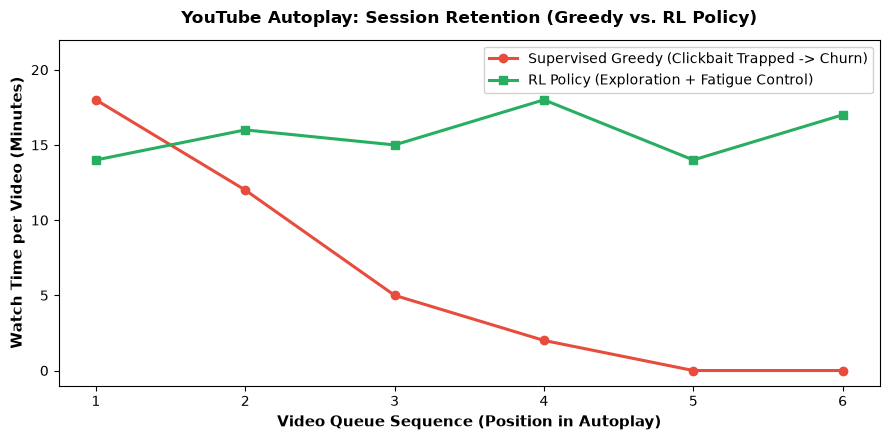

Total Session Watch Time (Greedy Supervised) : 37 minutes
Total Session Watch Time (RL-Optimized Policy) : 94 minutes (+57 mins, +154.1%)


In [4]:
# Python Simulation: Comparing Myopic Greedy vs. RL Autoplay Policy
np.random.seed(42)
n_sessions = 6

# Simulated user session engagement
greedy_watch_time = []
rl_watch_time = []

# Greedy policy gets trapped in repetitive clickbait (rapid drop in session length)
greedy_curve = [18, 12, 5, 2, 0, 0]  # User gets fatigued and quits

# RL policy balances variety, maintaining steady high engagement over time
rl_curve = [14, 16, 15, 18, 14, 17]  # Sustainable multi-video session

plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 7), greedy_curve, marker='o', lw=2.2, color='#e74c3c', label='Supervised Greedy (Clickbait Trapped -> Churn)')
plt.plot(range(1, 7), rl_curve, marker='s', lw=2.2, color='#27ae60', label='RL Policy (Exploration + Fatigue Control)')

plt.title('YouTube Autoplay: Session Retention (Greedy vs. RL Policy)', fontsize=12, weight='bold', pad=12)
plt.xlabel('Video Queue Sequence (Position in Autoplay)', fontsize=11, weight='bold')
plt.ylabel('Watch Time per Video (Minutes)', fontsize=11, weight='bold')
plt.ylim(-1, 22)
plt.xticks(range(1, 7))
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

print("=" * 70)
print(f"Total Session Watch Time (Greedy Supervised) : {sum(greedy_curve)} minutes")
print(f"Total Session Watch Time (RL-Optimized Policy) : {sum(rl_curve)} minutes (+{sum(rl_curve) - sum(greedy_curve)} mins, +{((sum(rl_curve)-sum(greedy_curve))/sum(greedy_curve))*100:.1f}%)")
print("=" * 70)


---
## Key Takeaways & Core Concepts

1. **Trial-and-Error Interaction**:
   Unlike Supervised Learning which requires passive teacher labels, RL agents learn active behavior through environmental interaction.
2. **The Exploration-Exploitation Dilemma**:
   A foundational challenge in RL is balancing **exploitation** (choosing the action known to produce good rewards) with **exploration** (trying unfamiliar actions to discover potentially superior long-term rewards).
3. **Delayed Rewards**:
   Actions taken early in a sequence (e.g. sacrificing a knight in chess, or playing a short introductory video on YouTube) may yield immediate zero or negative rewards but unlock massive cumulative returns later.
